# Setup Environment

In [392]:
# Automatically reload external Python modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [393]:
# imports
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import train_test_split


import Functions.load_datasets as load_datasets
import Functions.process_dataset as process_dataset
import Functions.by_card_by_person as by_card_by_person
import Functions.plot_ROC as plot_ROC

# Generate Datasets

In [394]:
datasets = load_datasets.load(noun_acc_dataset_train = 'Datasets/Generalization Train DataLong NounAcc.xlsx', 
                            clinical_dataset_train = 'Datasets/Generalization Train Clinical Dataset.xlsx',
                            linguistic_dataset_train = 'Datasets/Generalization Train Linguistics Dataset.xlsx',
                            networks_dataset_train = 'Datasets/Generalization Train Network Strength Dataset.xlsx',
                            noun_acc_dataset_new = 'Datasets/Generalization Test new pts new cards DataLong NounAcc only.xlsx',
                            clinical_dataset_new = 'Datasets/Generalization Test new patients Clinical Stroke Dataset.xlsx',
                            linguistic_dataset_new = 'Datasets/Generalization Test new cards Linguistics Dataset.xlsx',
                            networks_dataset_new = 'Datasets/Generalization Test new patients Network Strength Dataset.xlsx')

noun_acc_dataset_train = datasets['noun_acc_dataset_train']
clinical_dataset_train = datasets['clinical_dataset_train']
linguistic_dataset_train = datasets['linguistic_dataset_train']
networks_dataset_train = datasets['networks_dataset_train']
noun_acc_dataset_new = datasets['noun_acc_dataset_new']
clinical_dataset_new = datasets['clinical_dataset_new']
linguistic_dataset_new = datasets['linguistic_dataset_new']
networks_dataset_new = datasets['networks_dataset_new']


Loaded Datasets/Generalization Train DataLong NounAcc.xlsx, shape: (4620, 7)
Loaded Datasets/Generalization Train Clinical Dataset.xlsx, shape: (35, 20)
Loaded Datasets/Generalization Train Linguistics Dataset.xlsx, shape: (66, 8)
Loaded Datasets/Generalization Train Network Strength Dataset.xlsx, shape: (35, 84)
Loaded Datasets/Generalization Test new pts new cards DataLong NounAcc only.xlsx, shape: (1284, 7)
Loaded Datasets/Generalization Test new patients Clinical Stroke Dataset.xlsx, shape: (6, 20)
Loaded Datasets/Generalization Test new cards Linguistics Dataset.xlsx, shape: (6, 9)
Loaded Datasets/Generalization Test new patients Network Strength Dataset.xlsx, shape: (3, 84)


In [395]:
data_clin_train = pd.merge(noun_acc_dataset_train, clinical_dataset_train, on=["SubjID"])
data_ling_train = pd.merge(noun_acc_dataset_train, linguistic_dataset_train ,on=["Agent_Noun"])
data_nets_train = pd.merge(noun_acc_dataset_train, networks_dataset_train, on=["SubjID"])

# Generate clin_ling and all3 training datasets
data_clin_ling_train = pd.merge(data_clin_train, linguistic_dataset_train, on=["Agent_Noun"])
data_all3_train = pd.merge(data_clin_ling_train, networks_dataset_train, on=["SubjID"])

In [396]:
data_clin_new = pd.merge(noun_acc_dataset_new, clinical_dataset_new, on=["SubjID"])
data_ling_new = pd.merge(noun_acc_dataset_new, linguistic_dataset_new, on=["Agent_Noun"])
data_nets_new = pd.merge(noun_acc_dataset_new, networks_dataset_new, on=["SubjID"])

# Generate clin_ling and all3 new pts new cards datasets
data_clin_ling_new_pts_new_cards = pd.merge(data_clin_new, linguistic_dataset_new, on=["Agent_Noun"])
data_all3_new_pts_new_cards = pd.merge(data_clin_ling_new_pts_new_cards, networks_dataset_new, on=["SubjID"])

In [397]:
# Generate clin_ling: same pts new cards, new pts same cards datasets
data_clin_ling_same_pts_new_cards = pd.merge(noun_acc_dataset_new, clinical_dataset_train, on=["SubjID"])
data_clin_ling_same_pts_new_cards = pd.merge(data_clin_ling_same_pts_new_cards, linguistic_dataset_new, on=["Agent_Noun"])

data_clin_ling_new_pts_same_cards = pd.merge(data_clin_new, linguistic_dataset_train, on=["Agent_Noun"])

In [398]:
# Generate all3: same pts new cards, new pts same cards datasets
data_all3_same_pts_new_cards = pd.merge(data_clin_ling_same_pts_new_cards, networks_dataset_train, on=["SubjID"])

data_all3_new_pts_same_cards = pd.merge(data_clin_ling_new_pts_same_cards, networks_dataset_new, on=["SubjID"])



# Generate Datasets

In [399]:
X_clin_ling_train, y_clin_ling_train = process_dataset.preprocess_single_dataset(data_clin_ling_train)
X_all3_train, y_all3_train = process_dataset.preprocess_single_dataset(data_all3_train)

X_clin_ling_new_pts_new_cards, y_clin_ling_new_pts_new_cards = process_dataset.preprocess_single_dataset(data_clin_ling_new_pts_new_cards)
X_all3_new_pts_new_cards, y_all3_new_pts_new_cards = process_dataset.preprocess_single_dataset(data_all3_new_pts_new_cards)

X_clin_ling_same_pts_new_cards, y_clin_ling_same_pts_new_cards = process_dataset.preprocess_single_dataset(data_clin_ling_same_pts_new_cards)
X_all3_same_pts_new_cards, y_all3_same_pts_new_cards = process_dataset.preprocess_single_dataset(data_all3_same_pts_new_cards)

X_clin_ling_new_pts_same_cards, y_clin_ling_new_pts_same_cards = process_dataset.preprocess_single_dataset(data_clin_ling_new_pts_same_cards)
X_all3_new_pts_same_cards, y_all3_new_pts_same_cards = process_dataset.preprocess_single_dataset(data_all3_new_pts_same_cards)

X shape: (4620, 17)
y shape: (4620,)
Missing values in X: 0
X shape: (4620, 100)
y shape: (4620,)
Missing values in X: 0
X shape: (72, 17)
y shape: (72,)
Missing values in X: 0
X shape: (36, 100)
y shape: (36,)
Missing values in X: 0
X shape: (420, 17)
y shape: (420,)
Missing values in X: 0
X shape: (420, 100)
y shape: (420,)
Missing values in X: 0
X shape: (792, 17)
y shape: (792,)
Missing values in X: 0
X shape: (396, 100)
y shape: (396,)
Missing values in X: 0


In [400]:
X_clin_ling_new_pts_new_cards = X_clin_ling_new_pts_new_cards.drop(columns=['log10_lesion_vol'])
X_all3_new_pts_new_cards = X_all3_new_pts_new_cards.drop(columns=['log10_lesion_vol'])

X_clin_ling_same_pts_new_cards = X_clin_ling_same_pts_new_cards.drop(columns=['log10_lesion_vol'])
X_all3_same_pts_new_cards = X_all3_same_pts_new_cards.drop(columns=['log10_lesion_vol'])

X_clin_ling_new_pts_same_cards = X_clin_ling_new_pts_same_cards.drop(columns=['log10_lesion_vol'])
X_all3_new_pts_same_cards = X_all3_new_pts_same_cards.drop(columns=['log10_lesion_vol'])

X_clin_ling_train = X_clin_ling_train.drop(columns=['log10_lesion_vol'])
X_all3_train = X_all3_train.drop(columns=['log10_lesion_vol'])


In [401]:
_, X_test_clin_ling, _, y_test_clin_ling = train_test_split(X_clin_ling_train, y_clin_ling_train, test_size=0.2, stratify=y_clin_ling_train, random_state=42)

# Load models

In [402]:
clin_ling_rf_best_model = joblib.load('saved_models/clin_ling_rf_best_model.joblib')
all3_rf_best_model = joblib.load('saved_models/all3_rf_best_model.joblib')


# Testing Clin + Ling

## Test clin_ling model - new patients new cards

In [403]:
by_card_by_person.save_breakdowns_by_person_card(
    model = clin_ling_rf_best_model,
    X = X_clin_ling_new_pts_new_cards,
    y = y_clin_ling_new_pts_new_cards,
    data_with_meta = data_clin_ling_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="clin_ling_new_pts_new_cards_by_person.xlsx",
    out_card_excel="clin_ling_new_pts_new_cards_by_card.xlsx"
)


Saved: clin_ling_new_pts_new_cards_by_person.xlsx
Saved: clin_ling_new_pts_new_cards_by_card.xlsx


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Test clin_ling model - same patients new cards

In [404]:
by_card_by_person.save_breakdowns_by_person_card(
    model = clin_ling_rf_best_model,
    X = X_clin_ling_same_pts_new_cards,
    y = y_clin_ling_same_pts_new_cards,
    data_with_meta = data_clin_ling_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="clin_ling_same_pts_new_cards_by_person.xlsx",
    out_card_excel="clin_ling_same_pts_new_cards_by_card.xlsx"
)


Saved: clin_ling_same_pts_new_cards_by_person.xlsx
Saved: clin_ling_same_pts_new_cards_by_card.xlsx


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## Test clin_ling model - new patients same cards

In [405]:
by_card_by_person.save_breakdowns_by_person_card(
    model = clin_ling_rf_best_model,
    X = X_clin_ling_new_pts_same_cards,
    y = y_clin_ling_new_pts_same_cards,
    data_with_meta = data_clin_ling_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="clin_ling_new_pts_same_cards_by_person.xlsx",
    out_card_excel="clin_ling_new_pts_same_cards_by_card.xlsx"
)


Saved: clin_ling_new_pts_same_cards_by_person.xlsx
Saved: clin_ling_new_pts_same_cards_by_card.xlsx


# Testing All3 Model

## Test all3 model - new patients new cards

In [406]:
by_card_by_person.save_breakdowns_by_person_card(
    model = all3_rf_best_model,
    X = X_all3_new_pts_new_cards,
    y = y_all3_new_pts_new_cards,
    data_with_meta = data_all3_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="all3_new_pts_new_cards_by_person.xlsx",
    out_card_excel="all3_new_pts_new_cards_by_card.xlsx"
)


Saved: all3_new_pts_new_cards_by_person.xlsx
Saved: all3_new_pts_new_cards_by_card.xlsx


## Test all3 model - same patients new cards

In [407]:
by_card_by_person.save_breakdowns_by_person_card(
    model = all3_rf_best_model,
    X = X_all3_same_pts_new_cards,
    y = y_all3_same_pts_new_cards,
    data_with_meta = data_all3_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="all3_same_pts_new_cards_by_person.xlsx",
    out_card_excel="all3_same_pts_new_cards_by_card.xlsx"
)


Saved: all3_same_pts_new_cards_by_person.xlsx
Saved: all3_same_pts_new_cards_by_card.xlsx


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Test all3 model - new patients same cards

In [408]:
by_card_by_person.save_breakdowns_by_person_card(
    model = all3_rf_best_model,
    X = X_all3_new_pts_same_cards,
    y = y_all3_new_pts_same_cards,
    data_with_meta = data_all3_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="all3_new_pts_same_cards_by_person.xlsx",
    out_card_excel="all3_new_pts_same_cards_by_card.xlsx"
)


Saved: all3_new_pts_same_cards_by_person.xlsx
Saved: all3_new_pts_same_cards_by_card.xlsx


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

# ROC curves for generalization

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all m

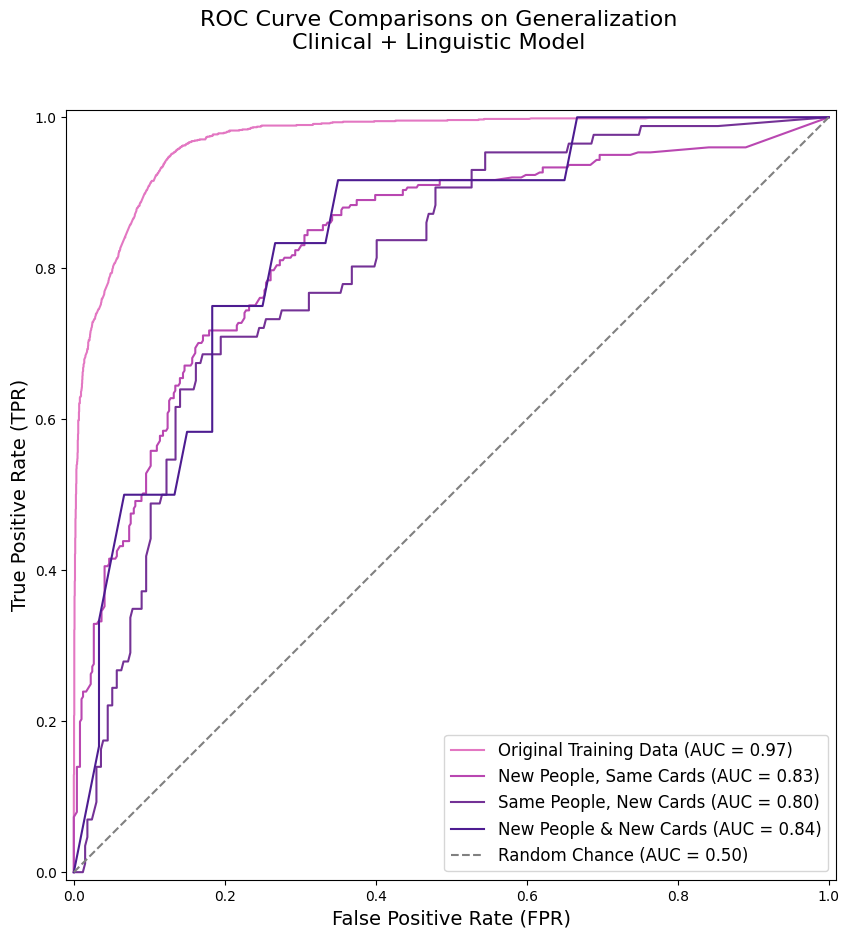

In [409]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot ROC curves on the same axis
clin_ling_disp = RocCurveDisplay.from_estimator(
    clin_ling_rf_best_model, X_clin_ling_train, y_clin_ling_train, color='tab:pink', ax=ax
)
same_cards_disp = RocCurveDisplay.from_estimator(
    clin_ling_rf_best_model, X_clin_ling_new_pts_same_cards, y_clin_ling_new_pts_same_cards, 
    ax=ax, color='#b947b1'
)
same_pts_disp = RocCurveDisplay.from_estimator(
    clin_ling_rf_best_model, X_clin_ling_same_pts_new_cards, y_clin_ling_same_pts_new_cards, 
    ax=ax, color='#743296'
)
all_new_disp = RocCurveDisplay.from_estimator(
    clin_ling_rf_best_model, X_clin_ling_new_pts_new_cards, y_clin_ling_new_pts_new_cards, 
    ax=ax, color='#4d1c91'
)

# Add random chance line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')

# Extract handles and create custom labels with AUC
handles, _ = ax.get_legend_handles_labels()
labels = [
    f'Original Training Data (AUC = {clin_ling_disp.roc_auc:.2f})',
    f'New People, Same Cards (AUC = {same_cards_disp.roc_auc:.2f})',
    f'Same People, New Cards (AUC = {same_pts_disp.roc_auc:.2f})',
    f'New People & New Cards (AUC = {all_new_disp.roc_auc:.2f})',
    'Random Chance (AUC = 0.50)'
]

# Add legend and labels
ax.legend(handles, labels, loc='lower right', fontsize=12)
ax.set_xlabel('False Positive Rate (FPR)', fontsize=14)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=14)
fig.suptitle("ROC Curve Comparisons on Generalization\nClinical + Linguistic Model", fontsize=16)

plt.show()


In [410]:
X_clin_ling_new_pts_new_cards.shape

(72, 16)

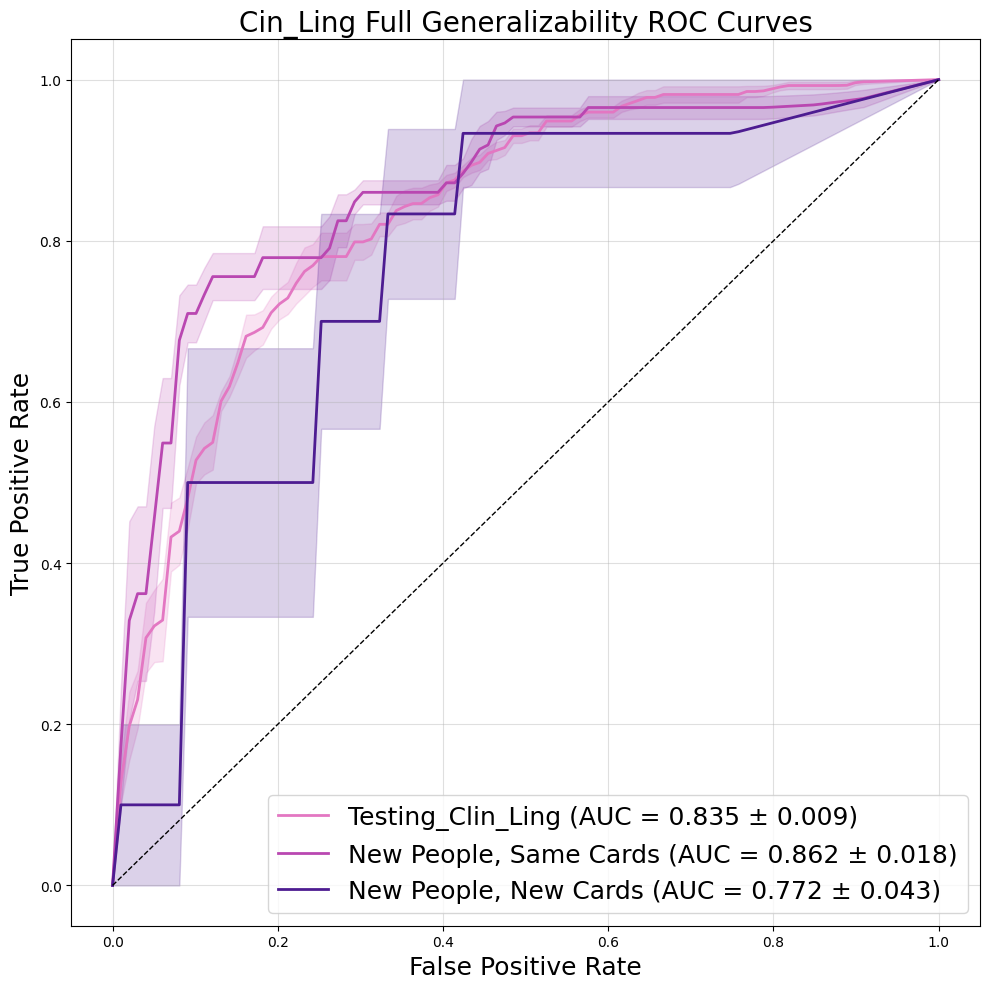

In [ ]:
rf_models = {
    "Testing_Clin_Ling": clin_ling_rf_best_model, 
    "New People, Same Cards": clin_ling_rf_best_model,
    "New People, New Cards": clin_ling_rf_best_model
}

X_dict = {
    "Testing_Clin_Ling": X_test_clin_ling, 
    "New People, Same Cards": X_clin_ling_same_pts_new_cards,
    "New People, New Cards": X_clin_ling_new_pts_new_cards
}
y_dict = {
    "Testing_Clin_Ling": y_test_clin_ling,
    "New People, Same Cards": y_clin_ling_same_pts_new_cards,
    "New People, New Cards": y_clin_ling_new_pts_new_cards
}

plot_ROC.plot_mean_rf_roc_sem(rf_models, X_dict, y_dict, title = '   ')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all m

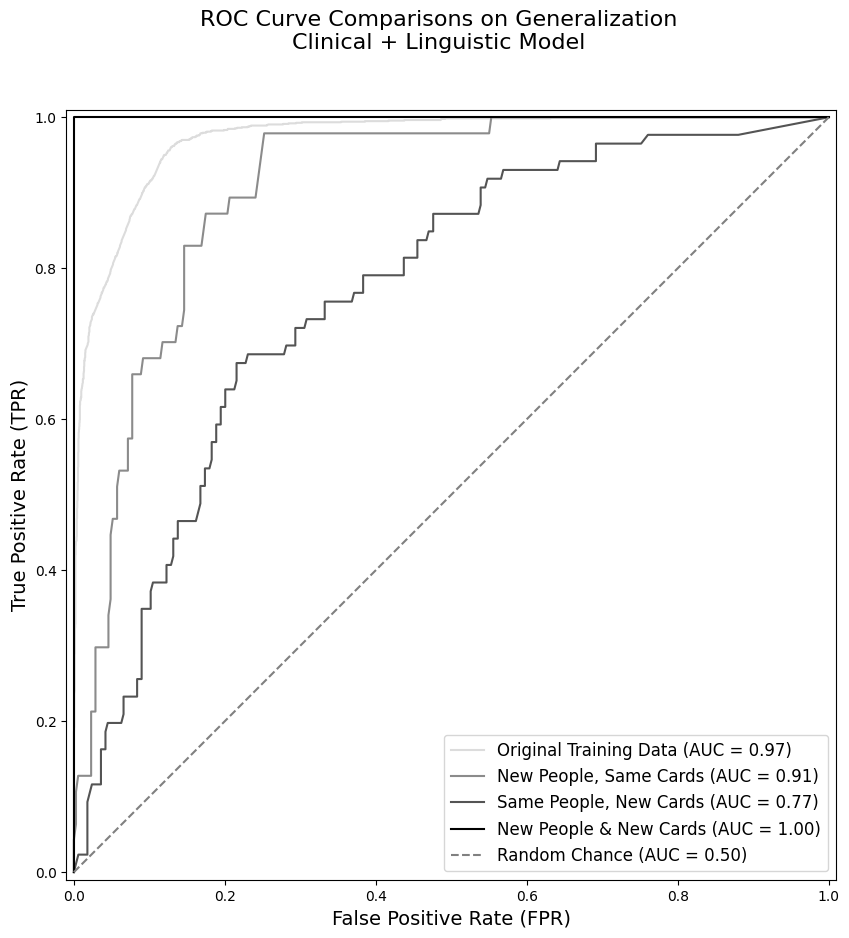

In [412]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot ROC curves on the same axis
all3_disp = RocCurveDisplay.from_estimator(
    all3_rf_best_model, X_all3_train, y_all3_train, color="#dcdcdc", ax=ax
)
same_cards_disp = RocCurveDisplay.from_estimator(
    all3_rf_best_model, X_all3_new_pts_same_cards, y_all3_new_pts_same_cards, 
    ax=ax, color="#8B8B8B"
)
same_pts_disp = RocCurveDisplay.from_estimator(
    all3_rf_best_model, X_all3_same_pts_new_cards, y_all3_same_pts_new_cards, 
    ax=ax, color="#545454"
)
all_new_disp = RocCurveDisplay.from_estimator(
    all3_rf_best_model, X_all3_new_pts_new_cards, y_all3_new_pts_new_cards, 
    ax=ax, color="#000000"
)

# Add random chance line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')

# Extract handles and create custom labels with AUC
handles, _ = ax.get_legend_handles_labels()
labels = [
    f'Original Training Data (AUC = {all3_disp.roc_auc:.2f})',
    f'New People, Same Cards (AUC = {same_cards_disp.roc_auc:.2f})',
    f'Same People, New Cards (AUC = {same_pts_disp.roc_auc:.2f})',
    f'New People & New Cards (AUC = {all_new_disp.roc_auc:.2f})',
    'Random Chance (AUC = 0.50)'
]

# Add legend and labels
ax.legend(handles, labels, loc='lower right', fontsize=12)
ax.set_xlabel('False Positive Rate (FPR)', fontsize=14)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=14)
fig.suptitle("ROC Curve Comparisons on Generalization\nClinical + Linguistic Model", fontsize=16)

plt.show()
